# Exercício Indivudual Estatística - Teste de Hipóteses

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from math import sqrt
from scipy.stats import norm
from scipy import stats

In [67]:
df_ab = pd.read_csv('experimento_teste_ab.csv')
df_ab.head()

,Visitante_ID,Versão_Página,Visualizações,Conversões
0,1,A,167,1
1,2,A,160,0
2,3,A,170,0
3,4,A,161,1
4,5,A,104,0


In [68]:
df_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Visitante_ID   2000 non-null   int64 
 1   Versão_Página  2000 non-null   object
 2   Visualizações  2000 non-null   int64 
 3   Conversões     2000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 62.6+ KB


In [69]:
# 1
df_ab.groupby('Versão_Página')['Conversões'].sum()

Versão_Página
A    105
B    125
Name: Conversões, dtype: int64

$$
n = \left( \frac{Z_{\alpha/2} \sqrt{2p(1-p)} + Z_{\beta} \sqrt{p_1(1-p_1) + p_2(1-p_2)}}{p_1 - p_2} \right)^2
$$

In [70]:
# 2

p1 = 105 / 1000  # taxa de conversão do grupo A
p2 = 0.10 + 0.10 * 0.10  # aumento esperado de 10%
alpha = 0.05
beta = 0.20  # 1 - poder do teste (80% de poder significa beta = 0.20)

# valores críticos para o nível de confiança (Z_alpha/2) e poder do teste (Z_beta)
z_alpha_2 = norm.ppf(1 - alpha / 2)  # z_alpha/2 para 95% de confiança
z_beta = norm.ppf(1 - beta)  # z_beta para 80% de poder

# Média das proporções
p = (p1 + p2) / 2
n = ((z_alpha_2 * sqrt(2 * p * (1 - p)) + z_beta * sqrt(p1 * (1 - p1) + p2 * (1 - p2))) / (p1 - p2)) ** 2

print(f'O tamanho da amostra necessária para o desenvolvimento de um teste A/B, nesse contexto, é de {n:.2f}')

O tamanho da amostra necessária para o desenvolvimento de um teste A/B, nesse contexto, é de 60242.90


---

In [71]:
df_pacientes = pd.read_csv('pacientes.csv')
df_pacientes.head()

,Unnamed: 0,Pressao_Arterial,Idade,Genero,Etnia,Estado_Saude,Nome_Genero,Nome_Etnia,Nome_Estado_Saude
0,0,142.755809,31,1,1,1,Feminino,Afro-americano,Com condições de saúde adicionais
1,1,161.878468,35,1,1,0,Feminino,Afro-americano,Saudável
2,2,161.508259,39,0,3,1,Masculino,Asiático,Com condições de saúde adicionais
3,3,144.979408,43,1,3,1,Feminino,Asiático,Com condições de saúde adicionais
4,4,162.502954,55,0,2,1,Masculino,Hispânico,Com condições de saúde adicionais


In [72]:
df_pacientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   Pressao_Arterial   1000 non-null   float64
 2   Idade              1000 non-null   int64  
 3   Genero             1000 non-null   int64  
 4   Etnia              1000 non-null   int64  
 5   Estado_Saude       1000 non-null   int64  
 6   Nome_Genero        1000 non-null   object 
 7   Nome_Etnia         1000 non-null   object 
 8   Nome_Estado_Saude  1000 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 70.4+ KB


In [73]:
# 3 Teste de Hipótese sobre Idade Média

indices = [909, 751, 402, 400, 726, 39, 184, 269, 255, 769, 209, 715,
           677, 381, 793, 697, 89, 280, 232, 756, 358, 36, 439, 768,
           967, 699, 473, 222, 89, 639, 883, 558, 757, 84, 907, 895,
           217, 224, 311, 348, 146, 505, 273, 957, 362]
amostra = df_pacientes.loc[indices, 'Idade']

# Teste t unilateral
media_amostra = amostra.mean()
n = len(amostra)
std_amostra = amostra.std(ddof=1)

# valor do teste t
t_stat = (media_amostra - 50) / (std_amostra / (n ** 0.5))

p_valor = 1 - stats.t.cdf(t_stat, df=n-1)

alpha = 0.05
resultado = ("Rejeita H0" if p_valor < alpha else "Não rejeita H0")

print(f"- Média da amostra: {media_amostra:.2f},\n- p-valor: {p_valor:.4f},\n- Resultado: {resultado}")


- Média da amostra: 50.09,
- p-valor: 0.4793,
- Resultado: Não rejeita H0


In [74]:
# 4

In [75]:
df_pacientes.Nome_Estado_Saude.unique()

array(['Com condições de saúde adicionais', 'Saudável'], dtype=object)

In [76]:
# 5 Teste de Hipótese sobre Pressão Arterial

indices_pressao = [690, 894, 67, 201, 364, 19, 60, 319, 588, 643, 855, 623, 530, 174, 105, 693, 6, 462, 973, 607, 811, 346, 354, 966, 943, 372]
amostra_pressao = df_pacientes.loc[indices_pressao]

# grupos
grupo_saude_adicional = amostra_pressao[amostra_pressao['Estado_Saude'] == 1]['Pressao_Arterial']
grupo_saude_normal = amostra_pressao[amostra_pressao['Estado_Saude'] == 0]['Pressao_Arterial']

# Teste t independente
t_stat, p_valor = stats.ttest_ind(grupo_saude_adicional, grupo_saude_normal)

alpha = 0.06
resultado = "Rejeita H0" if p_valor < alpha else "Não rejeita H0"

print(f"- Estatística t: {t_stat:.4f},\n- p-valor: {p_valor:.4f},\n- Resultado: {resultado}\n")


if resultado == "Rejeita H0":
    print("Concluímos que a pressão arterial média para pacientes com condições de saúde adicionais é\
 diferente da pressão arterial média para pacientes saudáveis.")
else:
    print("Não temos evidências suficientes para concluir que a pressão arterial média para pacientes\
 com condições de saúde adicionais é diferente da pressão arterial média para pacientes saudáveis.")


- Estatística t: 0.0812,
- p-valor: 0.9359,
- Resultado: Não rejeita H0

Não temos evidências suficientes para concluir que a pressão arterial média para pacientes com condições de saúde adicionais é diferente da pressão arterial média para pacientes saudáveis.


In [77]:
# 6 Teste ANOVA
anova_resultado = stats.f_oneway(*(df_pacientes[df_pacientes['Etnia'] == etnia]['Pressao_Arterial'] for etnia in df_pacientes['Etnia'].unique()))

alpha = 0.05
resultado = "Rejeita H0" if anova_resultado.pvalue < alpha else "Não rejeita H0"

print(f"p-valor ANOVA: {anova_resultado.pvalue:.4f}, Resultado: {resultado}")

p-valor ANOVA: 0.8738, Resultado: Não rejeita H0


In [78]:
# 7 Teste Qui-Quadrado

contingencia = pd.crosstab(df_pacientes['Genero'], df_pacientes['Estado_Saude'])
chi2_stat, p_valor, _, _ = stats.chi2_contingency(contingencia)

alpha = 0.05
resultado = "Rejeita H0" if p_valor < alpha else "Não rejeita H0"

print(f"- p-valor Qui-Quadrado: {p_valor:.4f},\n- Resultado: {resultado}")


- p-valor Qui-Quadrado: 1.0000,
- Resultado: Não rejeita H0


In [79]:
# 8 Intervalo de Confiaça

grupo_pressao_adicional = df_pacientes[df_pacientes['Estado_Saude'] == 1]['Pressao_Arterial']
media = grupo_pressao_adicional.mean()
std = grupo_pressao_adicional.std(ddof=1)
n = len(grupo_pressao_adicional)

# intervalo
erro_padrao = std / (n ** 0.5)
conf_interval = stats.t.interval(0.95, df=n-1, loc=media, scale=erro_padrao)

print(f"Com um Intervalo de confiança (95%) foi encontrada a seguinte faixa de valores: {conf_interval}")

Com um Intervalo de confiança (95%) foi encontrada a seguinte faixa de valores: (149.21972443653837, 151.01717945377672)


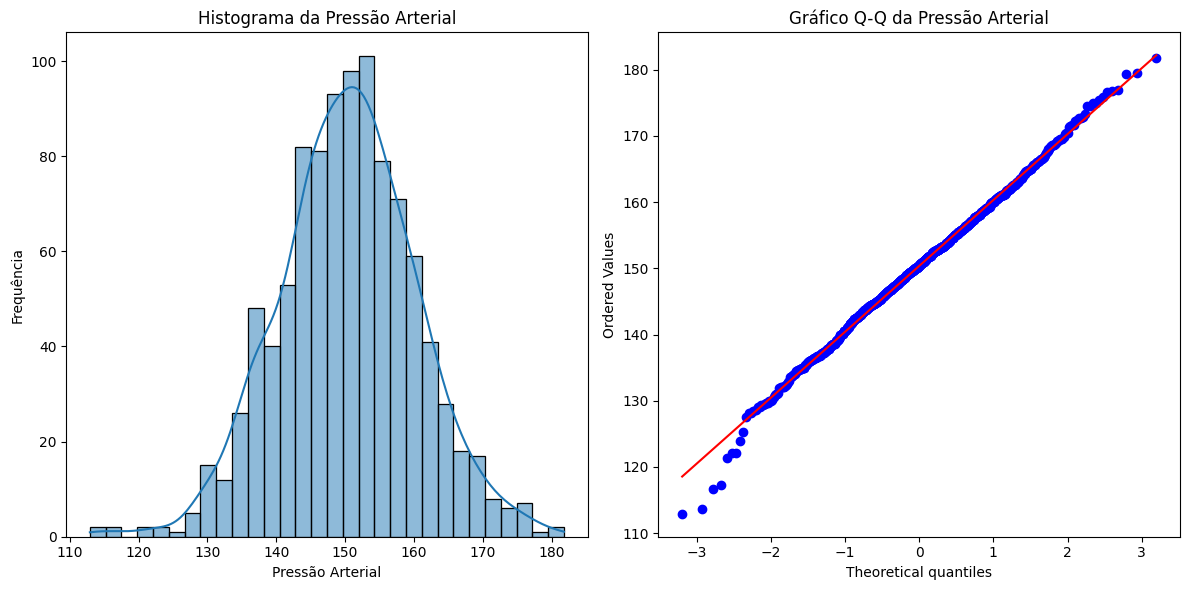

Não rejeita H0: A distribuição da pressão arterial parece ser normal.


In [80]:
# 9 Teste de normalidade (Shapiro-Wilk)

pressao_arterial = df_pacientes['Pressao_Arterial']

shapiro_stat, shapiro_p = stats.shapiro(pressao_arterial)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(pressao_arterial, bins=30, kde=True)
plt.title('Histograma da Pressão Arterial')
plt.xlabel('Pressão Arterial')
plt.ylabel('Frequência')

# Q-Q Plot
plt.subplot(1, 2, 2) 
stats.probplot(pressao_arterial, dist="norm", plot=plt)
plt.title('Gráfico Q-Q da Pressão Arterial')

plt.tight_layout()
plt.show()

# Resultado do teste de normalidade
alpha = 0.05
if shapiro_p > alpha:
    print("Não rejeita H0: A distribuição da pressão arterial parece ser normal.")
else:
    print("Rejeita H0: A distribuição da pressão arterial não parece ser normal.")


In [81]:
shapiro_stat

0.9970362186431885

In [82]:
shapiro_p

0.06068389490246773